# POLSCI 3

## Week 12, Notebook Lecture 1: Multivariate regression in observational studies

In this notebook and Notebook Lecture 2, we are going to look at two examples of multivariate regression using data from real studies.

The **example in this Notebook Lecture 1** explores a multivariate regression with **observational data**.  

The goal of "controlling for variables" is to reduce omitted variables bias.  However, we will see that there are reasons to be skeptical that the regression eliminates the bias.

This example will also let us practice **reading regression tables,** like those you see in many social science research papers.  

Finally, we will use the example to understand a bit more about how exactly multivariate regression tries to "control for" omitted variables.  This material is a bit more technical, and you are not responsible for knowing the coding or the technical details. But I want you to understand the main idea.

Then, in Notebook Lecture 2, we will look at another example that applies multivariate regression to a **randomized experiment.**  

Here the goal is different: we hope to increase precision (reduce standard errors of treatment effect estimators) through regression.  Omitted variable bias should already be eliminated by design: that is what randomization to treatment conditions accomplishes.


### Example: multivariate regression in an observational study

In this Notebook Lecture and in part of the in-class activity, we will use data on US House elections in 2018 and 2020.

In this data, every row is one Congressional district. There are 435 Congressional districts in the US, and each one has one representative in the US House of Representatives. For example, UC Berkeley is in California District 12, which looks like this:

<img src="CA12.png" />

Currently, Lateefah Simon is our representative, though for the time period recorded in the data our representative was Barbara Lee.

Let's read in the data:

In [8]:
library(ggplot2) # Allow us to make some graphs later
options(warn=-1) # suppresses R warnings we don't need

data <- read.csv("ps3-house-election-spending.csv")
head(data)

,state,district,name_dem_cand,name_rep_cand,dem_us_house_percent_2020,dem_us_house_percent_2018,dem_won_ushouse_2018,clinton_percent_2016,spending_dem_ushouse_2020,spending_rep_ushouse_2020
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,AL,1,"GARDNER, KIANI A","CARL, JERRY LEE, JR",35.53871,36.77648,0,34.93852,0.11866185,2.2325439
2,AL,2,"HARVEY-HALL, PHYLLIS","COLEMAN, JEFF",34.68272,38.42594,0,33.70786,0.05766116,2.6159773
3,AL,3,"WINFREY, ADIA","ROGERS, MICHAEL",32.45933,36.21845,0,33.09426,0.04122109,1.2283404
4,AL,4,"NEIGHBORS, RICKY","ADERHOLT, ROBERT B. REP.",17.68298,20.12911,0,17.79141,0.04790858,1.3521382
5,AL,5,"JOFFRION, PETER S.","BROOKS, MO",0.00000,38.89471,0,32.60417,0.00310696,0.2237067
6,AR,1,"CAUSEY, CHAD","CRAWFORD, ERIC ALAN RICK",0.00000,28.77438,0,31.72269,0.00060000,1.0955175


Here is a quick rundown of what each column means:

- `state`: State (e.g., for CA-13, "CA")
- `district`: District number (e.g., for CA-13, 13)
- `name_dem_cand`: Democrat candidate name in the 2020 US House elections
- `name_rep_cand`: Republican candidate name in the 2020 US House elections
- `dem_us_house_percent_2020`: Democrat candidate's vote share in 2020 election (percent)
- `dem_us_house_percent_2018`: Democrat candidate's vote share in 2018 election (percent)
- `dem_won_ushouse_2018`: A Democrat won the US House election in 2018, and so is running for re-election in 2020 (0 = lost, 1 = won)
- `clinton_percent_2016`: Clinton vote share in 2016 in the district (percent)
- `spending_dem_ushouse_2020`: Democratic US House candidate's spending in 2020, in millions of dollars 
- `spending_rep_ushouse_2020`: Republican US House candidate's spending in 2020, in millions of dollars 

### Does campaign spending work?

We'll use this data to see how multivariate regression can help us _try_ (not necessarily succeed) at reducing omitted variable bias when trying to understand the effects of campaign spending in US elections.

To make things easy, let's begin by subsetting the data to Democratic districts (where Democrats won the house election in 2018):

In [3]:
democrats <- subset(data, dem_won_ushouse_2018 == 1)
head(democrats)

,state,district,name_dem_cand,name_rep_cand,dem_us_house_percent_2020,dem_us_house_percent_2018,dem_won_ushouse_2018,clinton_percent_2016,spending_dem_ushouse_2020,spending_rep_ushouse_2020
,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
10,AZ,1,"O'HALLERAN, TOM","SHEDD, TIFFANY",51.61017,53.83161,1,49.41676,3.3596871,1.65523470
11,AZ,2,"KIRKPATRICK, ANN","MARTIN, BRANDON RAY",55.09586,54.73360,1,52.59809,1.4336623,0.38752702
12,AZ,3,"GRIJALVA, RAUL M","WOOD, DANIEL",64.57343,63.86546,1,65.75343,0.6912876,0.04248094
16,AZ,7,"GALLEGO, RUBEN","BARNETT, JOSH",76.69331,85.60632,1,76.05933,1.6686692,0.01788267
18,AZ,9,"SINEMA, KYRSTEN","GILES, DAVID VICTOR",61.62647,61.08557,1,58.75403,1.3410854,0.12993453
20,CA,2,"HUFFMAN, JARED","MENSING, DALE KENNETH",75.73794,77.00796,1,74.75623,0.8218126,0.00223573


Using bivariate regression we learned last week, what seems to be the "effect" of spending among Democratic incumbents? **Note: this regression is susceptible to omitted variable bias!!**

In [4]:
summary(lm(dem_us_house_percent_2020 ~ spending_dem_ushouse_2020, democrats))


Call:
lm(formula = dem_us_house_percent_2020 ~ spending_dem_ushouse_2020, 
    data = democrats)

Residuals:
    Min      1Q  Median      3Q     Max 
-36.745  -8.140  -2.573   7.551  61.408 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 66.078      1.245  53.090  < 2e-16 ***
spending_dem_ushouse_2020   -1.212      0.296  -4.094 6.07e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 13.45 on 209 degrees of freedom
Multiple R-squared:  0.07423,	Adjusted R-squared:  0.0698 
F-statistic: 16.76 on 1 and 209 DF,  p-value: 6.069e-05


Weird! For every \$1 million a Democratic Member of the US House spends on their re-election campaign, we predict that they do 1.2 percentage points *worse* in the upcoming election!

This is probably a result of **omitted variable bias.** Let's think, what might cause the "treatment" here (Democrats to spend money on their campaigns for re-election) and the outcome (Democrats' performance in the election).

One possibility: underlying partisan composition of the district. Some districts are evenly divided between Democratic and Republican voters. In these districts, Democrats only get around half the votes, and Democratic politicians spend a lot of money on campaigning since the election is so close. 

On the other hand, in "safe" districts (e.g., our own congressional district, where Barbara Lee won with 90.4\% of the vote in 2020), Democrats do well and they don't need to spend much money on their campaign.

In other words: incumbents who are in more competitive districts raise and spend more since they're more worried about losing. Incumbents in "safe seats" spend less. This makes incumbents who do less well in the election spend more, not because spending causes them to do worse, but because anticipating they will do worse causes them to spend!

#### Can multivariate regression fix this problem? (Spoiler alert: only partly)

Let's apply the idea of multivariate regression: "hold constant" these omitted variables, such as how "close" their district is. For example, let's control for how Democratic-leaning the district was in the 2016 Presidential election, _and_ how they performed in the last election.

In [5]:
summary(lm(dem_us_house_percent_2020 ~ spending_dem_ushouse_2020 +
           clinton_percent_2016 + dem_us_house_percent_2018, democrats))


Call:
lm(formula = dem_us_house_percent_2020 ~ spending_dem_ushouse_2020 + 
    clinton_percent_2016 + dem_us_house_percent_2018, data = democrats)

Residuals:
    Min      1Q  Median      3Q     Max 
-31.997  -2.373   0.026   2.137  39.802 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                6.15659    3.22338   1.910   0.0575 .  
spending_dem_ushouse_2020 -0.21580    0.18532  -1.164   0.2456    
clinton_percent_2016       0.78916    0.07449  10.594   <2e-16 ***
dem_us_house_percent_2018  0.10672    0.06561   1.627   0.1053    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.059 on 207 degrees of freedom
Multiple R-squared:  0.6707,	Adjusted R-squared:  0.6659 
F-statistic: 140.5 on 3 and 207 DF,  p-value: < 2.2e-16


Now, the "effect" of spending is statistically insignificant and the estimate is much smaller. But, we probably haven't solved omitted variable bias.

For example, another omitted variable could be the _quality of the challenger_: in some districts, a well-known or well-liked Republican might decide to run in 2020, and this might cause Democrats to spend more and to do less well in the election. 

However, how well-known or well-liked a Republican challenger is is quite difficult to measure; it's unlikely we would ever do a good job controlling for that potential omitted variable.

So, the **most important thing to remember**: you can never be sure you've solved omitted variable bias with multivariate regression. There could still be other possible omitted variables you're not thinking about. 

## Reading regression tables

Let's also use this example to practice reading tables of regression results.

Here are screenshots of some more regressions using this data set, predicting Democratic vote share in US House elections in 2020. 

The first regression subsets to districts with Democratic incumbents and studies the "effect" of spending by Democrats.  The second regression subsets to districts with Republican incumbents and studies the "effect" of spending by Republicans.  

Both regressions have the same two control variables: Clinton's percentage of the vote in 2016 and the Democratic percentage of the vote for the U.S. House representative in 2018.

<img src="week12_l1_lm.png" width="50%">

-----

<img src="week12_a1_lm.png" width="50%">

As a **regression table** in a paper, they would look like this:

<img src="week12_both_nice_table.png" width="60%">

There's a few things about this table that are common across almost all regression tables:
- Each **column** reports the results of one regression. Multiple columns means we are looking at the results of multiple different regressions (in this example, two). The **column titles** should tell you what is different about the regressions.
    - Sometimes this will be switching subsets of data (as in this example).
    - Sometimes it will involve switching _outcomes_.
    - Sometimes the outcome and subset will be the same, but new variables will be introduced into the regression.
    - You have to use context and the table notes to be sure what is changing across the columns.
- Each **row** represents the coefficients/estimates on one of the variables in the regression.
    - The **first column** shows the variable that is being estimated.
    - The **last row** of estimates contains the Intercept or Constant term (these are synonymous).
- In each **cell**, the first number is the coefficient, and the number in brackets below it is the standard error. These are the only numbers we need to calculate a t-statistic, confidence interval, and $p$-value.  
- The **stars** next to each number indicate if the estimates are statistically significant and, if so, how small the $p$-value is. (The **Table Notes** along the bottom will tell you how to interpret the stars.)
- **Missing cells** mean that this variable was not included in this regression. Sometimes it will just be blank, sometimes there will be a "-" to indicate it is being left blank on purpose.
- The **sample size** ($N$) and a statistic called $R^2$ are printed at the bottom of each column.
    - (I'm not focusing on the $R^2$ statistic in this class much, but it measures how much of the variation in the outcome the left-hand-side variables can predict.)
- There is a title that should help you interpret anything else about the table you need to know. (In practice, how helpful these notes are vary.)
- There are notes at the bottom that help you interpret anything else about the table you need to know. (In practice, how helpful these notes are vary.)

As we talked about in class, there is a lot going on "under the hood" to produce these numbers.  

For example, the standard errors depend on the assumption that "Nature" is sampling random error terms at random from a box.  Usually, it is said to sample in the same way each time from the same box.  This is often a pretty strong assumption.  

We don't have time or space in this class to unpack how the standard errors, t-statistics, confidence intervals, and $p$-values are constructed in the context of a multivariate regression analysis, but you should bear in mind that the validity and interpretation of these quantities can be a lot trickier in the case of multivariate regression on observational data.

Unlike in randomized experiments, in observational studies we do not control the process of treatment assignment and so cannot be sure of exactly how "random error" was in fact introduced (if that is even the right concept to apply).

### How exactly does multivariate regression "control" for other factors?

How multivariate regression works is actually really complicated. The fact that multivariate regression is so complicated is another red flag that you shouldn't assume it totally solves the omitted variable bias problem: if it's hard to understand what it is doing, how can we be sure it's doing the right thing?

But I do want to walk through a quick example to give you a bit of intuition about what is happening. **You don't need to learn the R commands in the rest of this notebook, but I do want you to understand the basic idea.**

Let's first start with a regression predicting how Democrat did in the 2020 election based on how Clinton did in the 2016 election in that same district, which is a way to measure the partisan lean of that district:

In [6]:
spending.lm <- lm(dem_us_house_percent_2020 ~ clinton_percent_2016, democrats)
summary(spending.lm)


Call:
lm(formula = dem_us_house_percent_2020 ~ clinton_percent_2016, 
    data = democrats)

Residuals:
    Min      1Q  Median      3Q     Max 
-32.394  -1.843   0.164   2.388  40.569 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)           5.65071    2.86325   1.974   0.0498 *  
clinton_percent_2016  0.90131    0.04439  20.304   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.105 on 209 degrees of freedom
Multiple R-squared:  0.6636,	Adjusted R-squared:  0.662 
F-statistic: 412.3 on 1 and 209 DF,  p-value: < 2.2e-16


Here's what is happening under the hood of that regression:

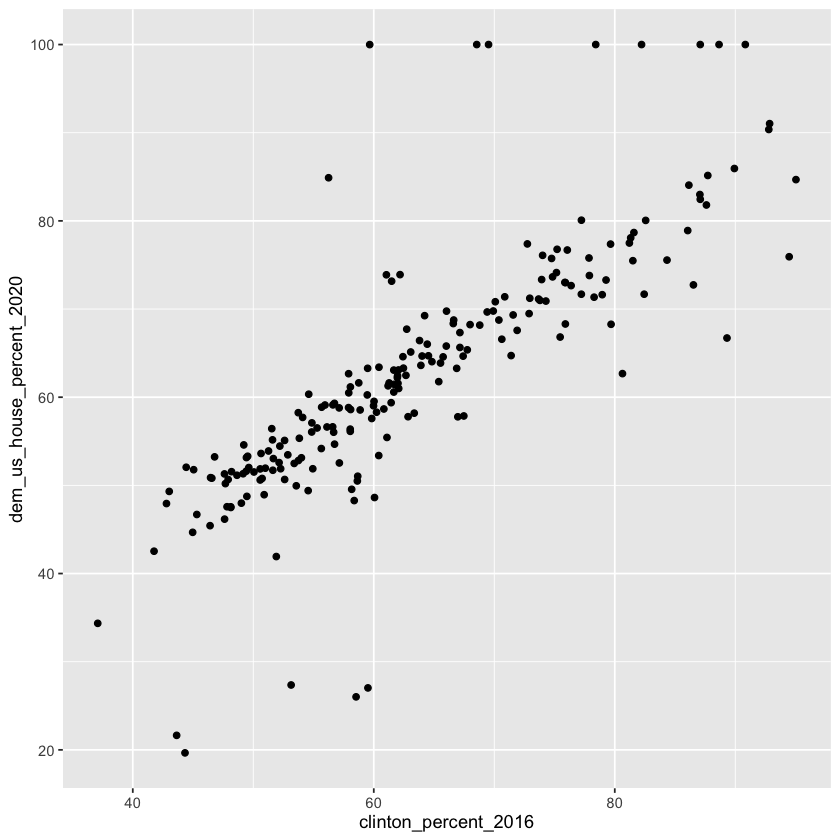

In [9]:
# It took this relationship:
qplot(clinton_percent_2016, dem_us_house_percent_2020, data = democrats)

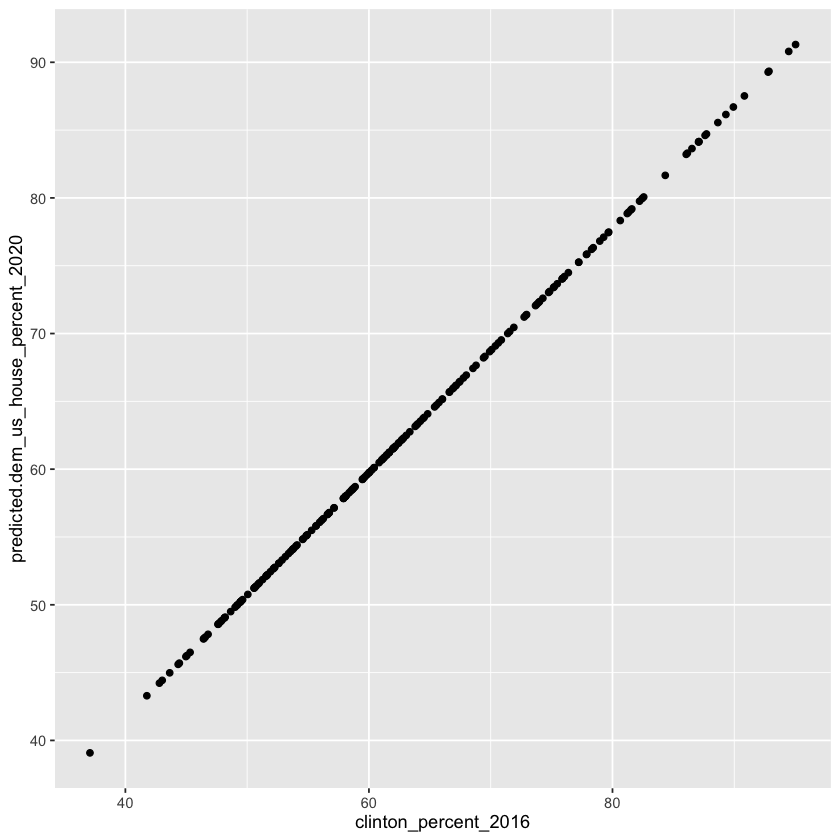

In [10]:
# ...the regression forms a "best guess" for every point, a prediction:
democrats$predicted.dem_us_house_percent_2020 <- predict(spending.lm)

# And found the best prediction based on drawing a line:
qplot(clinton_percent_2016, predicted.dem_us_house_percent_2020, data = democrats)

Let's see both on the same graph.

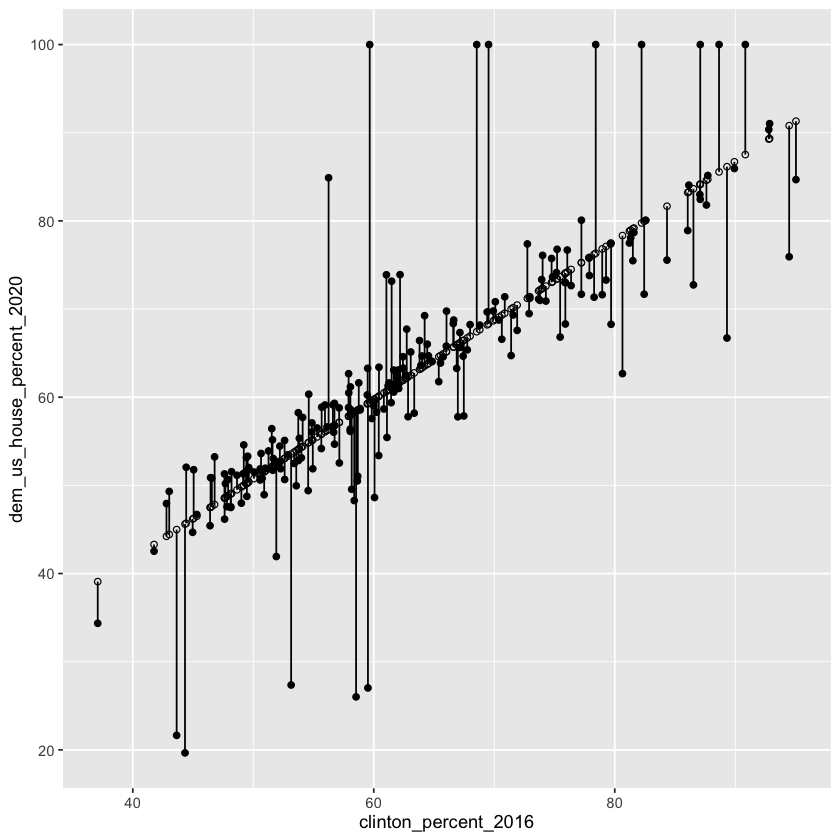

In [11]:
ggplot(democrats, aes(x = clinton_percent_2016, y = dem_us_house_percent_2020)) +
geom_segment(aes(xend = clinton_percent_2016, yend = predicted.dem_us_house_percent_2020)) +
  geom_point() +
  geom_point(aes(y = predicted.dem_us_house_percent_2020), shape = 1)

The lines I've drawn are called **residuals**. It's the information left over in the $y$ variable that can't be explained based on the first $x$ variable. That is, a multivariate regression "takes out the influence" of the other predictors, leaving only the residuals left. That's why they're called residuals - it's what is left over.

In [12]:
# The lines on the graph are called residuals.
democrats$residuals <- resid(spending.lm)

Let's next look at the relationship between spending and performance in 2020 *without* controlling for the underlying partisan lean of the district:

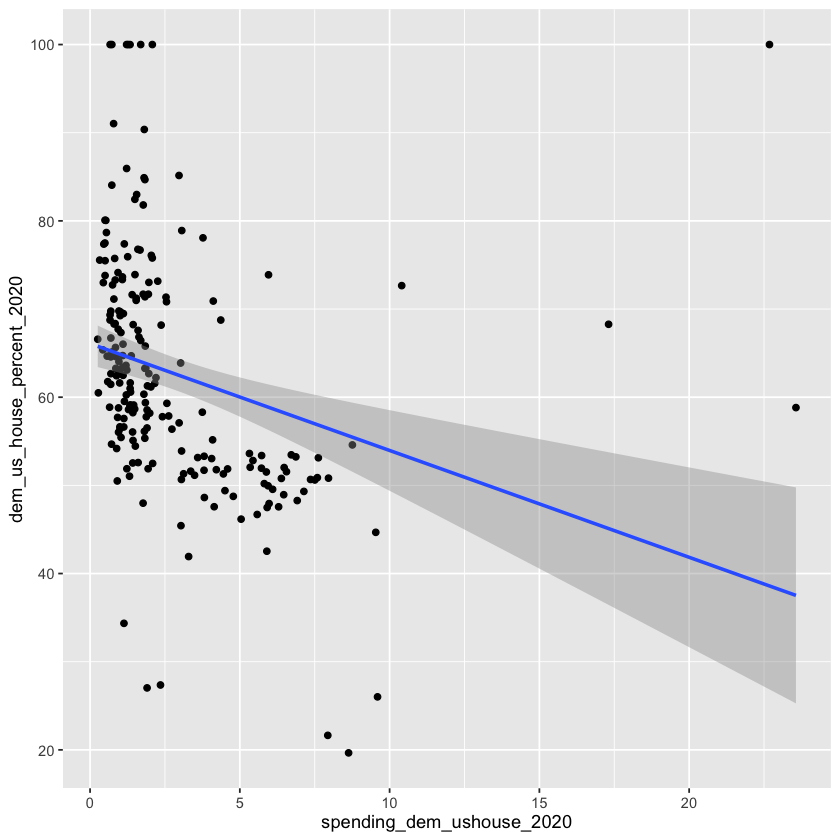

In [16]:
qplot(spending_dem_ushouse_2020, dem_us_house_percent_2020, data = democrats) + 
    geom_smooth(formula=y~x,method = 'lm') 

But what if, instead of regressing how Democrats did in 2020 on their campaign spending (as above), we try to *remove* the part of `dem_us_house_percent_2020` that can be explained by the partisan lean of the district? 

Basically, that is the information the residuals contain.  (I say "basically" because there is a little more going on under the hood: for example, we are removing the *linear* relationship between partisan lean of the district and Democratic vote share in 2020).

So what we can do is this: instead of regressing how Democrats did in 2020 on their campaign spending, we regress how Democrats did in 2020 on the *residuals* from the regression of campaign spending (`spending_dem_ushouse_2020`) on a measure of partisan lean (`clinton_percent_2016`).

And we can see that, when we removed the part of `spending_dem_ushouse_2020` that can be explained by `clinton_percent_2016`, the relationship gets way weaker:

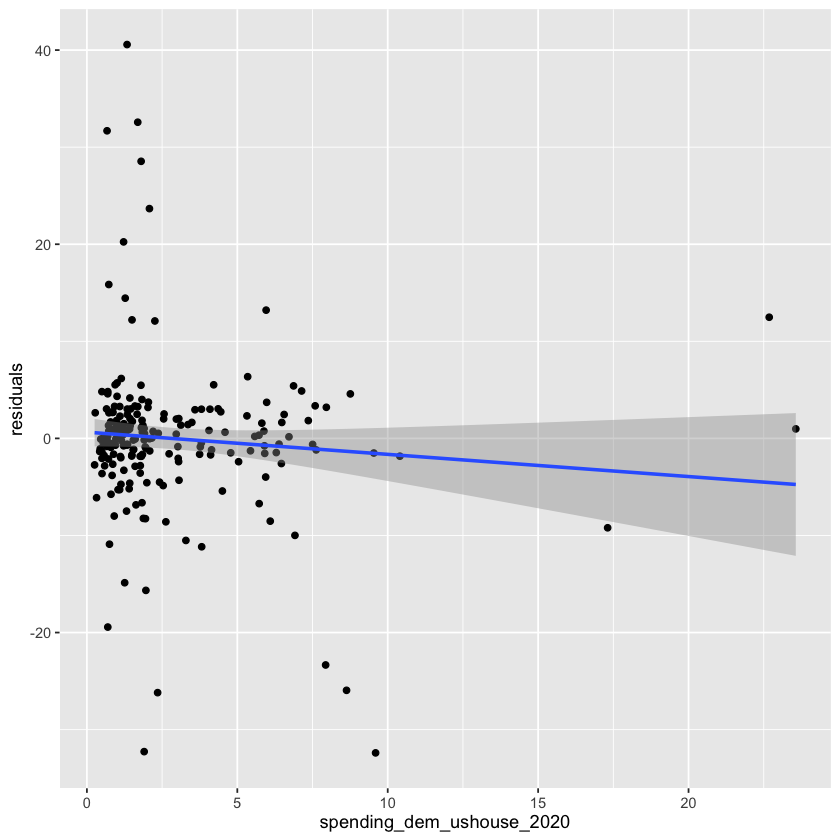

In [17]:
qplot(spending_dem_ushouse_2020, residuals, data = democrats) + 
    geom_smooth(formula=y~x,method = 'lm') 

This is basically what multivariate regression does: it gives us the relationship between two variables -- such as spending and Democratic performance in the 2020 elections -- after removing the influence of the other variables in the regression -- such as underlying district partisan lean.  

For example, in a multivariate regression of a district's Democratic vote share on campaign spending and partisan lean, the coefficient on campaign spending is the same coefficient we would get if we first regresses campaign spending on partisan lean, and then regressed Democratic vote share on the residuals from this first regression.

Multivariate regression then does the same thing for the "predictor" variable, too: so the numbers under `Estimate` next to each predictor variable tell us the relationship between _the variation in the outcome variable that cannot be explained by the other predictor variables_ and _the variation in that predictor variable that cannot be explained by the other predictor variables_.

In summary, then, multivariate regression is a way to understand the relationship between two variables while holding other variables constant. 

This can help us try to reduce omitted variable bias, but it's rare that this can solve omitted variable bias -- we might be missing other omitted variables!